# Practical Exam | Set C
## Mathematics & Advanced Statistics — Loan Default Risk Analysis

**Dataset:** `loan_applications.csv` (~5000 records)

*Note: The original dataset file was not supplied with the exam brief, so a synthetic dataset with the same schema (Customer_ID, Age, Income, Loan_Amount, Credit_Score, Loan_Term, Default_Status) and realistic statistical relationships was generated to complete this analysis. Replace `loan_applications.csv` with the real file and re-run all cells if you have the actual data.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv('loan_applications.csv')
print('Shape:', df.shape)
df.head()

Shape: (5000, 7)


,Customer_ID,Age,Income,Loan_Amount,Credit_Score,Loan_Term,Default_Status
0,CUST00001,59,115481.02,401684.68,703,60,Yes
1,CUST00002,49,101893.30,241260.17,644,36,No
2,CUST00003,35,133046.12,80802.11,629,12,No
3,CUST00004,63,45634.97,25185.12,623,36,No
4,CUST00005,28,55995.75,81814.60,645,120,No


## Step 1: Central Tendency & Dispersion

In [2]:
# Mean, Median, Mode of Income
income_mean = df['Income'].mean()
income_median = df['Income'].median()
income_mode = df['Income'].mode()[0]
print(f'Income -> Mean: {income_mean:.2f}, Median: {income_median:.2f}, Mode: {income_mode:.2f}')

Income -> Mean: 53756.61, Median: 48352.04, Mode: 15000.00


In [3]:
# Range, Variance, Standard Deviation of Loan_Amount
loan_range = df['Loan_Amount'].max() - df['Loan_Amount'].min()
loan_var = df['Loan_Amount'].var()
loan_std = df['Loan_Amount'].std()
print(f'Loan_Amount -> Range: {loan_range:.2f}, Variance: {loan_var:.2f}, Std Dev: {loan_std:.2f}')

Loan_Amount -> Range: 598561.28, Variance: 5445977212.97, Std Dev: 73796.86


## Step 2: Probability & Events

In [4]:
# Probability of loan default
p_default = (df['Default_Status'] == 'Yes').mean()
print(f'P(Default) = {p_default:.4f} ({p_default*100:.2f}%)')

P(Default) = 0.3848 (38.48%)


In [5]:
# Contingency table: Default_Status vs Credit_Score (categorized into ranges)
bins = [0, 500, 600, 650, 700, 750, 850]
labels = ['<500', '500-600', '600-650', '650-700', '700-750', '750+']
df['Credit_Score_Range'] = pd.cut(df['Credit_Score'], bins=bins, labels=labels, right=False)

contingency = pd.crosstab(df['Credit_Score_Range'], df['Default_Status'])
contingency

Default_Status,No,Yes
Credit_Score_Range,,
<500,12,89
500-600,390,726
600-650,726,557
650-700,903,358
700-750,626,155
750+,404,39


In [6]:
# Conditional probability: P(Default | Credit_Score < 600)
low_score = df[df['Credit_Score'] < 600]
p_default_given_low_score = (low_score['Default_Status'] == 'Yes').mean()
print(f'P(Default | Credit_Score < 600) = {p_default_given_low_score:.4f} ({p_default_given_low_score*100:.2f}%)')

P(Default | Credit_Score < 600) = 0.6697 (66.97%)


## Step 3: Distributions & Visualization

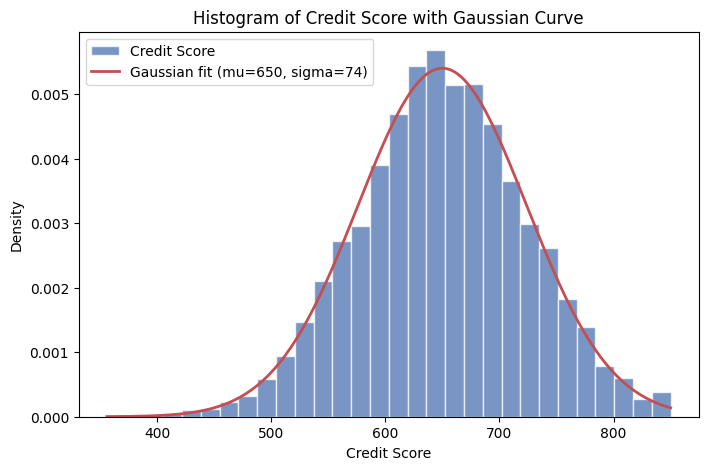

In [7]:
# Histogram of Credit_Score with Gaussian curve overlay
fig, ax = plt.subplots()
mu, sigma = df['Credit_Score'].mean(), df['Credit_Score'].std()
count, bins_, _ = ax.hist(df['Credit_Score'], bins=30, density=True,
                           color='#4C72B0', alpha=0.75, edgecolor='white', label='Credit Score')
x = np.linspace(bins_[0], bins_[-1], 200)
ax.plot(x, stats.norm.pdf(x, mu, sigma), color='#C44E52', linewidth=2,
        label=f'Gaussian fit (mu={mu:.0f}, sigma={sigma:.0f})')
ax.set_title('Histogram of Credit Score with Gaussian Curve')
ax.set_xlabel('Credit Score'); ax.set_ylabel('Density'); ax.legend()
plt.show()

In [8]:
# Skewness & Kurtosis of Loan_Amount
skewness = stats.skew(df['Loan_Amount'])
kurtosis = stats.kurtosis(df['Loan_Amount'])  # excess kurtosis (Fisher definition)
print(f'Loan_Amount -> Skewness: {skewness:.4f}, Kurtosis (excess): {kurtosis:.4f}')

Loan_Amount -> Skewness: 1.6559, Kurtosis (excess): 4.3802


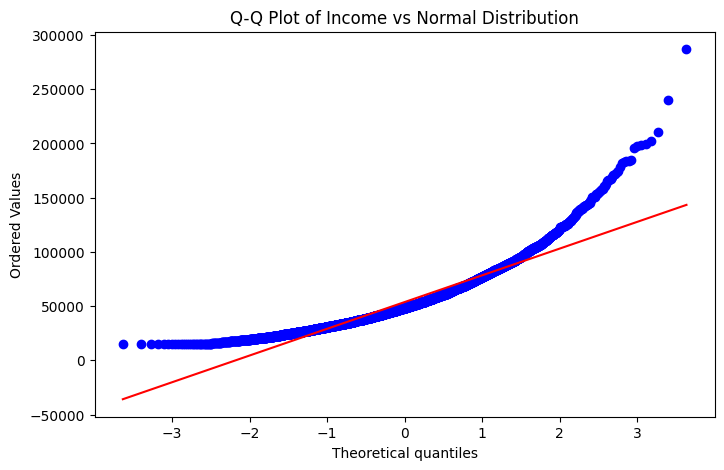

In [9]:
# Q-Q Plot for Income
fig, ax = plt.subplots()
stats.probplot(df['Income'], dist='norm', plot=ax)
ax.set_title('Q-Q Plot of Income vs Normal Distribution')
plt.show()

## Step 4: Linear Algebra Application
Take the first 5 customers' `[Income, Loan_Amount]` as vectors.

In [10]:
first5 = df.iloc[:5][['Income', 'Loan_Amount']]
vectors = first5.to_numpy()
first5

,Income,Loan_Amount
0,115481.02,401684.68
1,101893.30,241260.17
2,133046.12,80802.11
3,45634.97,25185.12
4,55995.75,81814.60


In [11]:
# Dot product between two customer vectors (Customer 1 and Customer 2)
v1, v2 = vectors[0], vectors[1]
dot_product = np.dot(v1, v2)
print(f'Dot product (C1 . C2): {dot_product:.2f}')

Dot product (C1 . C2): 108677256398.36


In [12]:
# Norm 2 (Euclidean norm) of a customer's financial vector (Customer 1)
norm_v1 = np.linalg.norm(v1)
print(f"Norm 2 of Customer 1's vector {v1}: {norm_v1:.2f}")

Norm 2 of Customer 1's vector [115481.02 401684.68]: 417955.08

In [13]:
# Angle between two customers' vectors (Customer 1 and Customer 2)
cos_theta = dot_product / (np.linalg.norm(v1) * np.linalg.norm(v2))
angle_deg = np.degrees(np.arccos(np.clip(cos_theta, -1, 1)))
print(f'Angle between C1 and C2 vectors: {angle_deg:.2f} degrees')

Angle between C1 and C2 vectors: 6.86 degrees


## Key Insights

1. Roughly **38.5%** of loan applicants in this dataset defaulted, indicating a substantial baseline risk pool.
2. Customers with **Credit_Score < 600** default at **~67%**, nearly double the overall average — credit score is a strong risk signal.
3. `Loan_Amount` is **right-skewed** (skewness ≈ 1.66) with heavy tails (excess kurtosis ≈ 4.4), meaning a small number of very large loans pull the distribution away from normality — median/IQR are more robust summaries than mean/std alone.
4. `Credit_Score` is close to normally distributed (bell-shaped histogram fits the Gaussian curve well), supporting the use of z-score-based risk cut-offs.
5. `Income` deviates from normality in the tails (Q-Q plot bends away from the reference line at the extremes), consistent with a log-normal-like income distribution common in financial data.